## Examples: Decision trees with sklearn

#### In this notebook, we will delve into the fundamentals of decision trees and how to implement them using sklearn. We'll cover how decision trees work, the training process, and practical implementation with Python's sklearn library. We will explore the decision-makind process, partitioning data, and evaluating model performance.

### Learning objectives
#### By the end of this notebook, you should be able to:
##### - Understand the conceptual structure and functionality of decision trees for regression.
##### - Train a decision tree model using sklearn.
##### - Implement recursive binary splitting to partition data effectively.
##### - Visualise decision tree models.

### Examples 

#### Example 1: Visualise the data

##### Suppose we are tasked with the problem of predicting the price of a house given its area using a dataset called `house_price_by_area`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/house_price_by_area.csv?raw=true')
df.head()

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


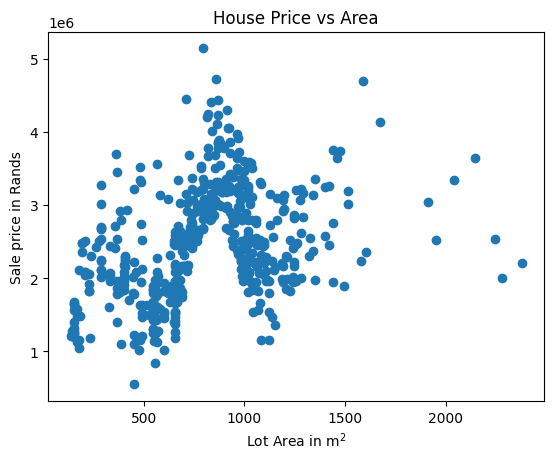

In [3]:
X = df['LotArea']
y = df['SalePrice']

plt.scatter(X, y)
plt.title('House Price vs Area')
plt.xlabel('Lot Area in m$^2$')
plt.ylabel('Sale price in Rands')
plt.show()

#### Example 2: Train-test split

In [5]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values.reshape(-1,1),
    y,
    test_size=0.2,
    random_state=42
)

### Example 3: Building the decision tree

In [10]:
from sklearn.tree import DecisionTreeRegressor

In [11]:
help(DecisionTreeRegressor)

Help on class DecisionTreeRegressor in module sklearn.tree._classes:

class DecisionTreeRegressor(sklearn.base.RegressorMixin, BaseDecisionTree)
 |  DecisionTreeRegressor(*, criterion='squared_error', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0)
 |  
 |  A decision tree regressor.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"squared_error", "friedman_mse", "absolute_error",             "poisson"}, default="squared_error"
 |      The function to measure the quality of a split. Supported criteria
 |      are "squared_error" for the mean squared error, which is equal to
 |      variance reduction as feature selection criterion and minimizes the L2
 |      loss using the mean of each terminal node, "friedman_mse", which uses
 |      mean squared error with Friedman's improv

In [12]:
# instantiate regression tree model
regr_tree = DecisionTreeRegressor(max_depth=2, random_state=42)

In [13]:
regr_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

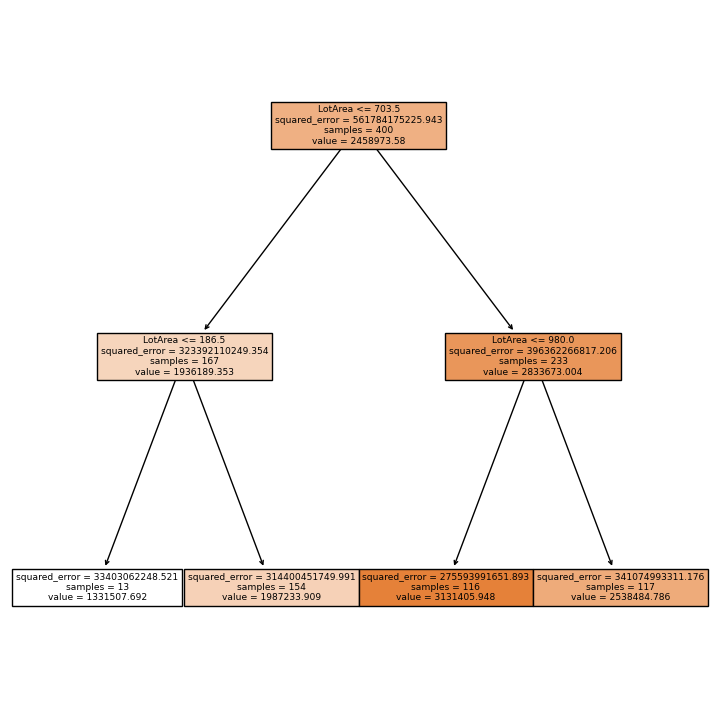

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(9,9))
# Assigned a random variable name to the plot to suppress text output
_ = plot_tree(regr_tree, feature_names=['LotArea'], filled=True)

### Example 4: Evaluating model performance

In [17]:
from sklearn.metrics import mean_squared_error

# get predictions for test data
y_pred = regr_tree.predict(X_test)

# calculate MSE
MSE = mean_squared_error(y_pred, y_test)

# Report RMSE
print("Regression decision tree model RMSE is:", np.sqrt(MSE))

Regression decision tree model RMSE is: 625573.2843752672


### Example 5: Visualising model output

In [20]:
# Generate a range of equidistant points along the x-axis spanning from the minimum
# to the maximum X-values in the dataset, consisting of 100 points.
x_domain = np.linspace(min(X), max(X), 100)[:, np.newaxis]

In [19]:
# Predict y for every point in x-domain
y_predictions = regr_tree.predict(X_domain)

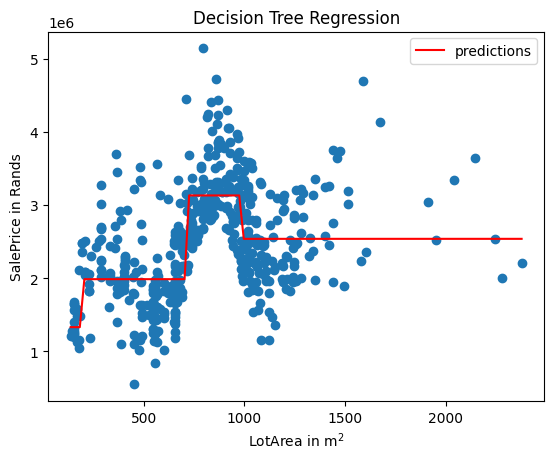

In [21]:
# plot the regression tree line over data
plt.figure()
plt.scatter(X, y)
plt.plot(x_domain, y_predictions, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalePrice in Rands')
plt.title('Decision Tree Regression')
plt.legend()
plt.show()